=== CHECKING DATASET DIRECTORY ===
Directory exists: /root/projects/my-herosim/simulation_data/artifacts/run7_big_bad/gnn_datasets
Contents: ['ds_00211', 'ds_01538', 'ds_00810', 'ds_01129', 'ds_01825', 'ds_02143', 'ds_01401', 'ds_01577', 'ds_02299', 'ds_00278']...
Found 2237 dataset directories
First few: ['ds_00211', 'ds_01538', 'ds_00810', 'ds_01129', 'ds_01825']

Contents of /root/projects/my-herosim/simulation_data/artifacts/run7_big_bad/gnn_datasets/ds_00211:
  best.json
  space_with_network.json
  run.log
  optimal_result.json
  workload.json

=== LOADING DATASETS ===
Looking for datasets in: /root/projects/my-herosim/simulation_data/artifacts/run7_big_bad/gnn_datasets
Found 2237 dataset directories
Processing dataset 1/2237: ds_00006
Processing dataset 101/2237: ds_00166
Processing dataset 201/2237: ds_00266
Processing dataset 301/2237: ds_00379
Processing dataset 401/2237: ds_00481
Processing dataset 501/2237: ds_00581
Processing dataset 601/2237: ds_00681
Processing dataset 70

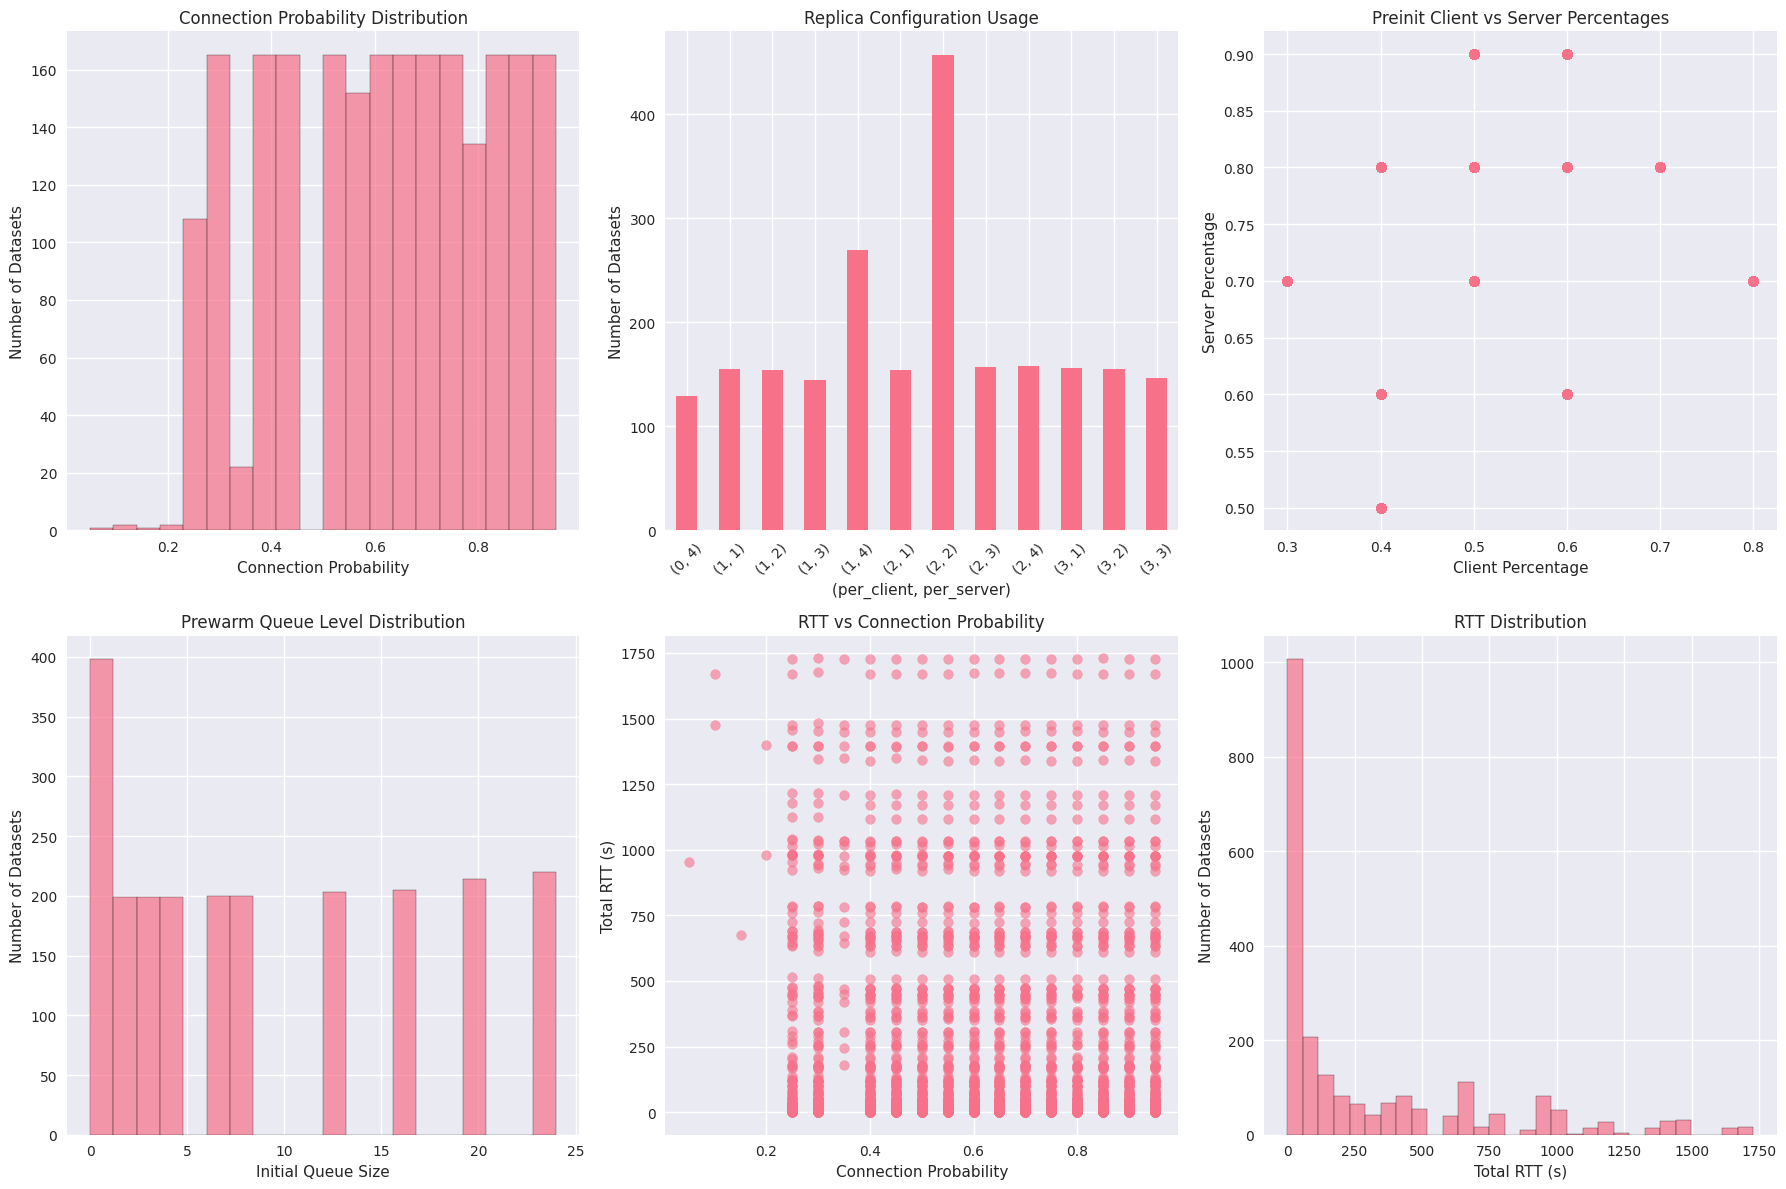

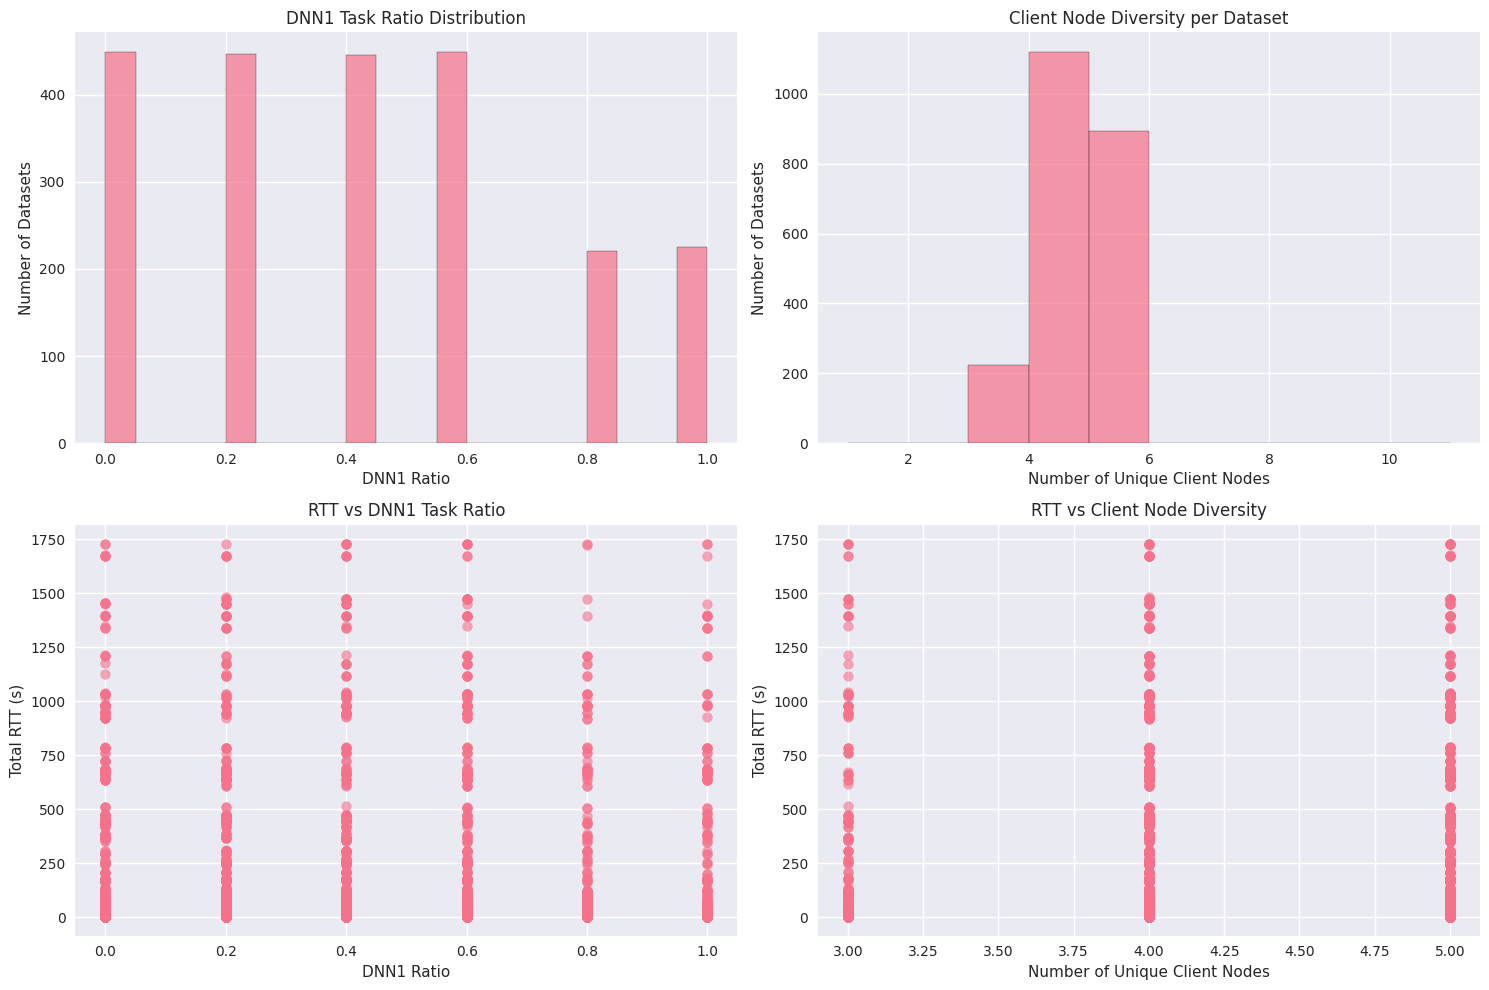


=== CORRELATION ANALYSIS ===


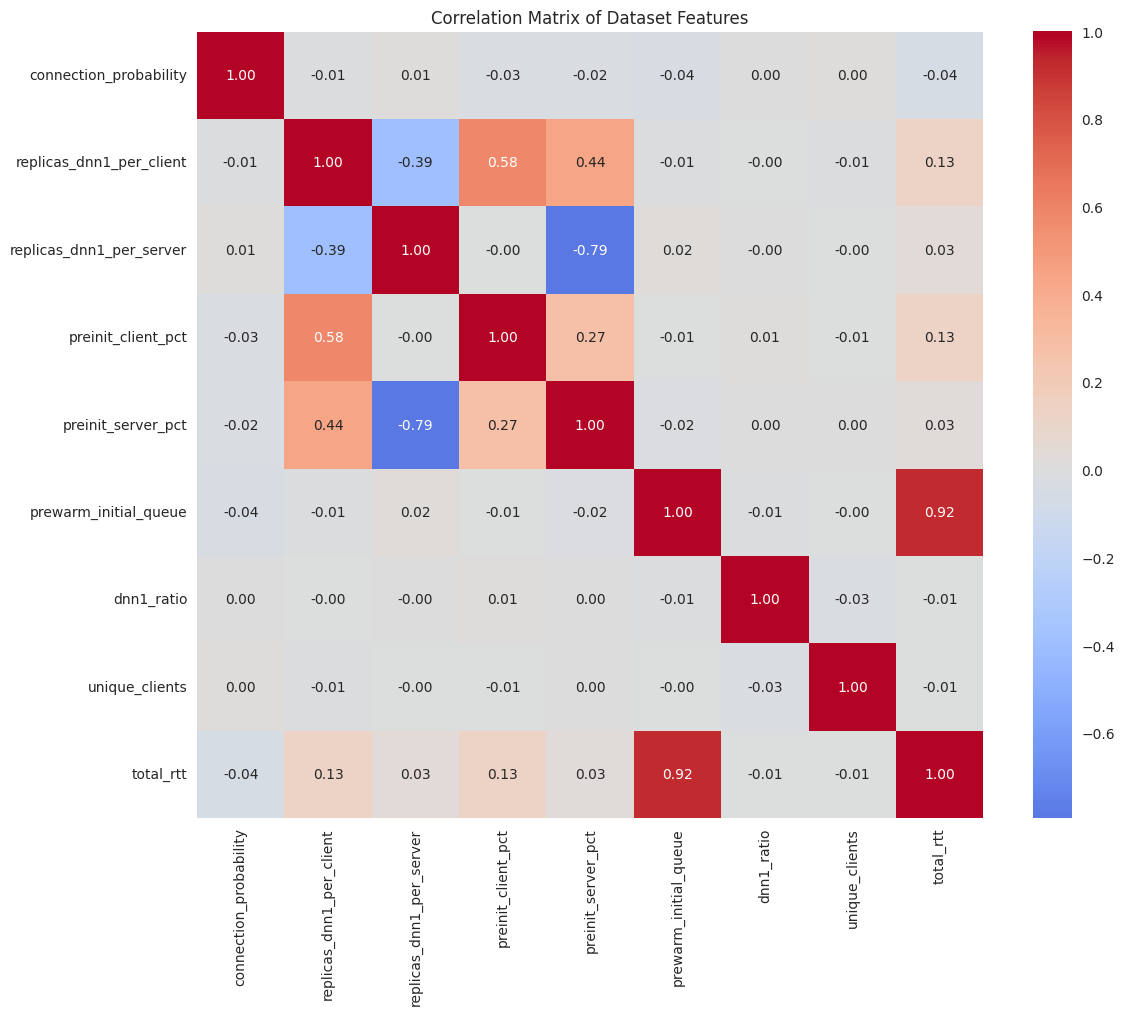


Strongest correlations with RTT:
  prewarm_initial_queue: 0.917
  preinit_client_pct: 0.130
  replicas_dnn1_per_client: 0.129
  connection_probability: 0.044
  replicas_dnn1_per_server: 0.035
  preinit_server_pct: 0.032
  unique_clients: 0.009
  dnn1_ratio: 0.006

=== DIVERSITY METRICS ===
  connection_probability: 19 unique values (diversity: 0.008)
  replicas_dnn1_per_client: 4 unique values (diversity: 0.002)
  replicas_dnn1_per_server: 4 unique values (diversity: 0.002)
  preinit_client_pct: 6 unique values (diversity: 0.003)
  preinit_server_pct: 5 unique values (diversity: 0.002)
  prewarm_initial_queue: 11 unique values (diversity: 0.005)
  Average infrastructure diversity: 0.004
  dnn1_ratio: 6 unique values (diversity: 0.003)
  unique_clients: 3 unique values (diversity: 0.001)
  Average workload diversity: 0.002
  RTT coefficient of variation: 1.362
  RTT range: 0.568s to 1729.601s (span: 1729.033s)

=== GNN TRAINING SUITABILITY ===
Feature Diversity Check:
  ✅ connection_pr

In [4]:
# GNN Dataset Analysis
# Analyze the diversity and quality of generated datasets for GNN training
# Copy these cells to a Jupyter notebook for interactive analysis

# Cell 1: Imports and Setup
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Cell 2: Load Dataset Information
def load_dataset_info(dataset_dir):
    """Load information from all generated datasets"""
    dataset_dir = Path(dataset_dir)
    datasets = []
    
    print(f"Looking for datasets in: {dataset_dir}")
    
    # Find all ds_* directories
    ds_dirs = [d for d in dataset_dir.glob('ds_*') if d.is_dir()]
    print(f"Found {len(ds_dirs)} dataset directories")
    
    for i, ds_path in enumerate(sorted(ds_dirs)):
        if i % 100 == 0:  # Progress indicator
            print(f"Processing dataset {i+1}/{len(ds_dirs)}: {ds_path.name}")
            
        try:
            # Check if required files exist
            required_files = ['space_with_network.json', 'workload.json', 'best.json', 'optimal_result.json']
            missing_files = [f for f in required_files if not (ds_path / f).exists()]
            
            if missing_files:
                print(f"  Skipping {ds_path.name}: Missing files {missing_files}")
                continue
            
            # Load configuration
            with open(ds_path / 'space_with_network.json', 'r') as f:
                config = json.load(f)
            
            # Load workload
            with open(ds_path / 'workload.json', 'r') as f:
                workload = json.load(f)
            
            # Load results
            with open(ds_path / 'best.json', 'r') as f:
                best = json.load(f)
            
            # Load optimal result
            with open(ds_path / 'optimal_result.json', 'r') as f:
                optimal = json.load(f)
            
            # Extract key information
            dataset_info = {
                'dataset_id': ds_path.name,
                'connection_probability': config['network']['topology']['connection_probability'],
                'replicas_dnn1_per_client': config['replicas']['dnn1']['per_client'],
                'replicas_dnn1_per_server': config['replicas']['dnn1']['per_server'],
                'replicas_dnn2_per_client': config['replicas']['dnn2']['per_client'],
                'replicas_dnn2_per_server': config['replicas']['dnn2']['per_server'],
                'preinit_client_pct': config['preinit']['client_percentage'],
                'preinit_server_pct': config['preinit']['server_percentage'],
                'prewarm_initial_queue': config['prewarm']['dnn1']['initial_queue'],
                'workload_rps': workload['rps'],
                'workload_duration': workload['duration'],
                'num_tasks': len(workload['events']),
                'total_rtt': best['rtt'],
                'optimal_file': best['file']
            }
            
            # Analyze workload task types
            task_types = [event['application']['name'].split('-')[1] for event in workload['events']]
            dataset_info['dnn1_count'] = task_types.count('dnn1')
            dataset_info['dnn2_count'] = task_types.count('dnn2')
            dataset_info['dnn1_ratio'] = dataset_info['dnn1_count'] / dataset_info['num_tasks']
            
            # Analyze client node distribution
            client_nodes = [event['node_name'] for event in workload['events']]
            dataset_info['unique_clients'] = len(set(client_nodes))
            dataset_info['client_distribution'] = dict(Counter(client_nodes))
            
            # Analyze task results from optimal simulation
            task_results = optimal['stats']['taskResults']
            if task_results:
                dataset_info['avg_elapsed_time'] = np.mean([tr['elapsedTime'] for tr in task_results])
                dataset_info['std_elapsed_time'] = np.std([tr['elapsedTime'] for tr in task_results])
                dataset_info['min_elapsed_time'] = np.min([tr['elapsedTime'] for tr in task_results])
                dataset_info['max_elapsed_time'] = np.max([tr['elapsedTime'] for tr in task_results])
                
                # Platform usage analysis
                platforms = [tr['platform']['shortName'] for tr in task_results]
                dataset_info['unique_platforms'] = len(set(platforms))
                dataset_info['platform_distribution'] = dict(Counter(platforms))
                
                # Cold start analysis
                cold_starts = [tr['coldStarted'] for tr in task_results]
                dataset_info['cold_start_ratio'] = sum(cold_starts) / len(cold_starts)
                
                # Network latency analysis
                network_latencies = [tr['networkLatency'] for tr in task_results if 'networkLatency' in tr]
                if network_latencies:
                    dataset_info['avg_network_latency'] = np.mean(network_latencies)
                    dataset_info['std_network_latency'] = np.std(network_latencies)
            
            datasets.append(dataset_info)
            
        except Exception as e:
            print(f"  Error loading {ds_path}: {e}")
            continue
    
    print(f"Successfully loaded {len(datasets)} datasets")
    return pd.DataFrame(datasets)

# Cell 3: Load and Basic Statistics
dataset_dir = "/root/projects/my-herosim/simulation_data/artifacts/run7_big_bad/gnn_datasets"

# First, let's check what's actually in the directory
print("=== CHECKING DATASET DIRECTORY ===")
import os
if os.path.exists(dataset_dir):
    files = os.listdir(dataset_dir)
    print(f"Directory exists: {dataset_dir}")
    print(f"Contents: {files[:10]}...")  # Show first 10 items
    
    # Check if there are any ds_* directories
    ds_dirs = [f for f in files if f.startswith('ds_') and os.path.isdir(os.path.join(dataset_dir, f))]
    print(f"Found {len(ds_dirs)} dataset directories")
    if ds_dirs:
        print(f"First few: {ds_dirs[:5]}")
        
        # Check what's in the first dataset directory
        first_ds = os.path.join(dataset_dir, ds_dirs[0])
        print(f"\nContents of {first_ds}:")
        for item in os.listdir(first_ds):
            print(f"  {item}")
else:
    print(f"Directory does not exist: {dataset_dir}")

print("\n=== LOADING DATASETS ===")
df = load_dataset_info(dataset_dir)

print(f"Total datasets loaded: {len(df)}")
if len(df) > 0:
    print(f"Available columns: {list(df.columns)}")
    print(f"Dataset ID range: {df['dataset_id'].min()} to {df['dataset_id'].max()}")
    
    if 'total_rtt' in df.columns:
        print(f"RTT range: {df['total_rtt'].min():.3f}s to {df['total_rtt'].max():.3f}s")
        print(f"Average RTT: {df['total_rtt'].mean():.3f}s ± {df['total_rtt'].std():.3f}s")
    else:
        print("No RTT data found in datasets")
else:
    print("No datasets loaded - check the directory structure and file contents")

# Cell 3.5: Debug - Check what's actually in the datasets
if len(df) > 0:
    print("\n=== DEBUG: Sample Dataset Structure ===")
    sample_ds = df.iloc[0]
    print("Sample dataset info:")
    for col, val in sample_ds.items():
        print(f"  {col}: {val}")
    
    # Check if we can load a raw dataset file
    import os
    sample_path = f"{dataset_dir}/ds_00000"
    if os.path.exists(sample_path):
        print(f"\nRaw files in {sample_path}:")
        for file in os.listdir(sample_path):
            print(f"  {file}")
        
        # Try to load a raw config file
        try:
            with open(f"{sample_path}/space_with_network.json", 'r') as f:
                raw_config = json.load(f)
            print(f"\nRaw config structure:")
            print(f"  Keys: {list(raw_config.keys())}")
            if 'network' in raw_config:
                print(f"  Network keys: {list(raw_config['network'].keys())}")
        except Exception as e:
            print(f"Error loading raw config: {e}")
else:
    print("No datasets loaded - check dataset directory path")

# Cell 4: Infrastructure Diversity Analysis
def analyze_infrastructure_diversity(df):
    """Analyze diversity in infrastructure configurations"""
    print("=== INFRASTRUCTURE DIVERSITY ===")
    
    # Connection probability distribution
    if 'connection_probability' in df.columns:
        print(f"\nConnection Probabilities:")
        print(f"  Range: {df['connection_probability'].min():.2f} to {df['connection_probability'].max():.2f}")
        print(f"  Unique values: {df['connection_probability'].nunique()}")
    else:
        print("\nConnection Probabilities: Column not found")
    
    # Replica configuration diversity
    replica_cols = ['replicas_dnn1_per_client', 'replicas_dnn1_per_server', 
                   'replicas_dnn2_per_client', 'replicas_dnn2_per_server']
    existing_replica_cols = [col for col in replica_cols if col in df.columns]
    
    if existing_replica_cols:
        replica_configs = df.groupby(existing_replica_cols).size()
        print(f"\nReplica Configurations:")
        print(f"  Unique combinations: {len(replica_configs)}")
        print(f"  Most common: {replica_configs.idxmax()} (used {replica_configs.max()} times)")
    else:
        print("\nReplica Configurations: Columns not found")
    
    # Preinit percentage diversity
    if 'preinit_client_pct' in df.columns and 'preinit_server_pct' in df.columns:
        print(f"\nPreinit Percentages:")
        print(f"  Client: {df['preinit_client_pct'].min():.1f} to {df['preinit_client_pct'].max():.1f}")
        print(f"  Server: {df['preinit_server_pct'].min():.1f} to {df['preinit_server_pct'].max():.1f}")
    else:
        print("\nPreinit Percentages: Columns not found")
    
    # Prewarm queue diversity
    if 'prewarm_initial_queue' in df.columns:
        print(f"\nPrewarm Queue Levels:")
        print(f"  Range: {df['prewarm_initial_queue'].min()} to {df['prewarm_initial_queue'].max()}")
        print(f"  Unique values: {df['prewarm_initial_queue'].nunique()}")
    else:
        print("\nPrewarm Queue Levels: Column not found")

analyze_infrastructure_diversity(df)

# Cell 5: Workload Diversity Analysis
def analyze_workload_diversity(df):
    """Analyze diversity in workload patterns"""
    print("\n=== WORKLOAD DIVERSITY ===")
    
    # Task type distribution
    if 'dnn1_ratio' in df.columns:
        print(f"\nTask Type Ratios:")
        print(f"  DNN1 ratio range: {df['dnn1_ratio'].min():.2f} to {df['dnn1_ratio'].max():.2f}")
        print(f"  DNN1 ratio distribution:")
        for ratio in sorted(df['dnn1_ratio'].unique()):
            count = (df['dnn1_ratio'] == ratio).sum()
            print(f"    {ratio:.2f}: {count} datasets")
    else:
        print("\nTask Type Ratios: Column not found")
    
    # Client node distribution
    if 'unique_clients' in df.columns:
        print(f"\nClient Node Distribution:")
        print(f"  Unique clients per dataset: {df['unique_clients'].min()} to {df['unique_clients'].max()}")
        print(f"  Average unique clients: {df['unique_clients'].mean():.2f}")
    else:
        print("\nClient Node Distribution: Column not found")
    
    # Analyze which client nodes are used most
    if 'client_distribution' in df.columns:
        all_clients = []
        for clients in df['client_distribution']:
            if isinstance(clients, dict):
                all_clients.extend(clients.keys())
        if all_clients:
            client_usage = Counter(all_clients)
            print(f"  Most used clients: {dict(client_usage.most_common(5))}")
    else:
        print("  Client distribution analysis: Column not found")

analyze_workload_diversity(df)

# Cell 6: Performance Diversity Analysis
def analyze_performance_diversity(df):
    """Analyze diversity in performance characteristics"""
    print("\n=== PERFORMANCE DIVERSITY ===")
    
    # RTT distribution
    if 'total_rtt' in df.columns:
        print(f"\nRTT Distribution:")
        print(f"  Range: {df['total_rtt'].min():.3f}s to {df['total_rtt'].max():.3f}s")
        print(f"  Mean: {df['total_rtt'].mean():.3f}s")
        print(f"  Median: {df['total_rtt'].median():.3f}s")
        print(f"  Std: {df['total_rtt'].std():.3f}s")
        
        # Performance quartiles
        q25, q50, q75 = df['total_rtt'].quantile([0.25, 0.5, 0.75])
        print(f"  Quartiles: Q1={q25:.3f}s, Q2={q50:.3f}s, Q3={q75:.3f}s")
    else:
        print("\nRTT Distribution: Column not found")
    
    # Platform diversity
    if 'unique_platforms' in df.columns:
        print(f"\nPlatform Usage:")
        print(f"  Unique platforms per dataset: {df['unique_platforms'].min()} to {df['unique_platforms'].max()}")
        print(f"  Average platforms used: {df['unique_platforms'].mean():.2f}")
    else:
        print("\nPlatform Usage: Column not found")
    
    # Cold start analysis
    if 'cold_start_ratio' in df.columns:
        print(f"\nCold Start Analysis:")
        print(f"  Cold start ratio range: {df['cold_start_ratio'].min():.2f} to {df['cold_start_ratio'].max():.2f}")
        print(f"  Average cold start ratio: {df['cold_start_ratio'].mean():.2f}")
    else:
        print("\nCold Start Analysis: Column not found")

analyze_performance_diversity(df)

# Cell 7: Visualization - Infrastructure Diversity
def plot_infrastructure_diversity(df):
    """Create visualizations for infrastructure diversity"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Connection probability distribution
    axes[0,0].hist(df['connection_probability'], bins=20, alpha=0.7, edgecolor='black')
    axes[0,0].set_title('Connection Probability Distribution')
    axes[0,0].set_xlabel('Connection Probability')
    axes[0,0].set_ylabel('Number of Datasets')
    
    # Replica configurations
    replica_counts = df.groupby(['replicas_dnn1_per_client', 'replicas_dnn1_per_server']).size()
    replica_counts.plot(kind='bar', ax=axes[0,1])
    axes[0,1].set_title('Replica Configuration Usage')
    axes[0,1].set_xlabel('(per_client, per_server)')
    axes[0,1].set_ylabel('Number of Datasets')
    axes[0,1].tick_params(axis='x', rotation=45)
    
    # Preinit percentages
    axes[0,2].scatter(df['preinit_client_pct'], df['preinit_server_pct'], alpha=0.6)
    axes[0,2].set_title('Preinit Client vs Server Percentages')
    axes[0,2].set_xlabel('Client Percentage')
    axes[0,2].set_ylabel('Server Percentage')
    
    # Prewarm queue levels
    axes[1,0].hist(df['prewarm_initial_queue'], bins=20, alpha=0.7, edgecolor='black')
    axes[1,0].set_title('Prewarm Queue Level Distribution')
    axes[1,0].set_xlabel('Initial Queue Size')
    axes[1,0].set_ylabel('Number of Datasets')
    
    # RTT vs Connection Probability
    axes[1,1].scatter(df['connection_probability'], df['total_rtt'], alpha=0.6)
    axes[1,1].set_title('RTT vs Connection Probability')
    axes[1,1].set_xlabel('Connection Probability')
    axes[1,1].set_ylabel('Total RTT (s)')
    
    # RTT distribution
    axes[1,2].hist(df['total_rtt'], bins=30, alpha=0.7, edgecolor='black')
    axes[1,2].set_title('RTT Distribution')
    axes[1,2].set_xlabel('Total RTT (s)')
    axes[1,2].set_ylabel('Number of Datasets')
    
    plt.tight_layout()
    plt.show()

plot_infrastructure_diversity(df)

# Cell 8: Visualization - Workload Diversity
def plot_workload_diversity(df):
    """Create visualizations for workload diversity"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Task type ratio distribution
    axes[0,0].hist(df['dnn1_ratio'], bins=20, alpha=0.7, edgecolor='black')
    axes[0,0].set_title('DNN1 Task Ratio Distribution')
    axes[0,0].set_xlabel('DNN1 Ratio')
    axes[0,0].set_ylabel('Number of Datasets')
    
    # Client node diversity
    axes[0,1].hist(df['unique_clients'], bins=range(1, 12), alpha=0.7, edgecolor='black')
    axes[0,1].set_title('Client Node Diversity per Dataset')
    axes[0,1].set_xlabel('Number of Unique Client Nodes')
    axes[0,1].set_ylabel('Number of Datasets')
    
    # RTT vs Task Type Ratio
    axes[1,0].scatter(df['dnn1_ratio'], df['total_rtt'], alpha=0.6)
    axes[1,0].set_title('RTT vs DNN1 Task Ratio')
    axes[1,0].set_xlabel('DNN1 Ratio')
    axes[1,0].set_ylabel('Total RTT (s)')
    
    # RTT vs Client Diversity
    axes[1,1].scatter(df['unique_clients'], df['total_rtt'], alpha=0.6)
    axes[1,1].set_title('RTT vs Client Node Diversity')
    axes[1,1].set_xlabel('Number of Unique Client Nodes')
    axes[1,1].set_ylabel('Total RTT (s)')
    
    plt.tight_layout()
    plt.show()

plot_workload_diversity(df)

# Cell 9: Correlation Analysis
def analyze_correlations(df):
    """Analyze correlations between different factors"""
    print("\n=== CORRELATION ANALYSIS ===")
    
    # Select numeric columns for correlation
    numeric_cols = ['connection_probability', 'replicas_dnn1_per_client', 'replicas_dnn1_per_server',
                   'preinit_client_pct', 'preinit_server_pct', 'prewarm_initial_queue',
                   'dnn1_ratio', 'unique_clients', 'total_rtt']
    
    # Filter to existing columns
    numeric_cols = [col for col in numeric_cols if col in df.columns]
    
    corr_matrix = df[numeric_cols].corr()
    
    # Plot correlation heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, fmt='.2f')
    plt.title('Correlation Matrix of Dataset Features')
    plt.tight_layout()
    plt.show()
    
    # Print strongest correlations with RTT
    rtt_correlations = corr_matrix['total_rtt'].abs().sort_values(ascending=False)
    print("\nStrongest correlations with RTT:")
    for feature, corr in rtt_correlations.items():
        if feature != 'total_rtt':
            print(f"  {feature}: {corr:.3f}")

analyze_correlations(df)

# Cell 10: Diversity Metrics
def calculate_diversity_metrics(df):
    """Calculate quantitative diversity metrics"""
    print("\n=== DIVERSITY METRICS ===")
    
    # Infrastructure diversity
    infra_features = ['connection_probability', 'replicas_dnn1_per_client', 
                     'replicas_dnn1_per_server', 'preinit_client_pct', 
                     'preinit_server_pct', 'prewarm_initial_queue']
    
    infra_diversity = 0
    for feature in infra_features:
        if feature in df.columns:
            unique_values = df[feature].nunique()
            total_possible = len(df)
            diversity = unique_values / total_possible
            infra_diversity += diversity
            print(f"  {feature}: {unique_values} unique values (diversity: {diversity:.3f})")
    
    infra_diversity /= len(infra_features)
    print(f"  Average infrastructure diversity: {infra_diversity:.3f}")
    
    # Workload diversity
    workload_features = ['dnn1_ratio', 'unique_clients']
    workload_diversity = 0
    for feature in workload_features:
        if feature in df.columns:
            unique_values = df[feature].nunique()
            total_possible = len(df)
            diversity = unique_values / total_possible
            workload_diversity += diversity
            print(f"  {feature}: {unique_values} unique values (diversity: {diversity:.3f})")
    
    workload_diversity /= len(workload_features)
    print(f"  Average workload diversity: {workload_diversity:.3f}")
    
    # Performance diversity
    if 'total_rtt' in df.columns:
        rtt_cv = df['total_rtt'].std() / df['total_rtt'].mean()
        print(f"  RTT coefficient of variation: {rtt_cv:.3f}")
        
        # RTT range coverage
        rtt_min, rtt_max = df['total_rtt'].min(), df['total_rtt'].max()
        rtt_range = rtt_max - rtt_min
        print(f"  RTT range: {rtt_min:.3f}s to {rtt_max:.3f}s (span: {rtt_range:.3f}s)")

calculate_diversity_metrics(df)

# Cell 11: GNN Training Suitability Analysis
def analyze_gnn_training_suitability(df):
    """Analyze how suitable the datasets are for GNN training"""
    print("\n=== GNN TRAINING SUITABILITY ===")
    
    # Check for sufficient diversity in key features
    print("Feature Diversity Check:")
    
    # Infrastructure diversity
    infra_diverse = True
    for feature in ['connection_probability', 'replicas_dnn1_per_client', 'replicas_dnn1_per_server']:
        if feature in df.columns:
            unique_vals = df[feature].nunique()
            if unique_vals < 3:
                print(f"  ⚠️  {feature}: Only {unique_vals} unique values (may be too limited)")
                infra_diverse = False
            else:
                print(f"  ✅ {feature}: {unique_vals} unique values")
    
    # Workload diversity
    workload_diverse = True
    if 'dnn1_ratio' in df.columns:
        unique_ratios = df['dnn1_ratio'].nunique()
        if unique_ratios < 5:
            print(f"  ⚠️  dnn1_ratio: Only {unique_ratios} unique ratios (may be too limited)")
            workload_diverse = False
        else:
            print(f"  ✅ dnn1_ratio: {unique_ratios} unique ratios")
    
    # Performance diversity
    if 'total_rtt' in df.columns:
        rtt_cv = df['total_rtt'].std() / df['total_rtt'].mean()
        if rtt_cv < 0.5:
            print(f"  ⚠️  RTT: Low variation (CV={rtt_cv:.3f}) - may limit learning")
        else:
            print(f"  ✅ RTT: Good variation (CV={rtt_cv:.3f})")
    
    # Overall assessment
    print(f"\nOverall Assessment:")
    if infra_diverse and workload_diverse:
        print("  ✅ Datasets appear suitable for GNN training")
        print("  ✅ Good diversity in infrastructure and workload patterns")
    else:
        print("  ⚠️  Datasets may have limited diversity for GNN training")
        print("  💡 Consider generating more datasets with varied parameters")

analyze_gnn_training_suitability(df)

# Cell 12: Export Analysis Results
def export_analysis_results(df, output_dir="/root/projects/my-herosim/analysis_results"):
    """Export analysis results for further use"""
    os.makedirs(output_dir, exist_ok=True)
    
    # Export processed dataframe
    df.to_csv(f"{output_dir}/processed_datasets.csv", index=False)
    
    # Export summary statistics
    summary = {
        'total_datasets': len(df),
        'rtt_range': [df['total_rtt'].min(), df['total_rtt'].max()],
        'rtt_mean': df['total_rtt'].mean(),
        'rtt_std': df['total_rtt'].std(),
        'infrastructure_diversity': df[['connection_probability', 'replicas_dnn1_per_client', 
                                      'replicas_dnn1_per_server', 'preinit_client_pct', 
                                      'preinit_server_pct', 'prewarm_initial_queue']].nunique().to_dict(),
        'workload_diversity': df[['dnn1_ratio', 'unique_clients']].nunique().to_dict()
    }
    
    with open(f"{output_dir}/summary.json", 'w') as f:
        json.dump(summary, f, indent=2)
    
    print(f"Analysis results exported to {output_dir}/")
    print(f"  - processed_datasets.csv: Full dataset information")
    print(f"  - summary.json: Summary statistics")

export_analysis_results(df)

# Cell 13: Final Recommendations
def generate_recommendations(df):
    """Generate recommendations for improving dataset diversity"""
    print("\n=== RECOMMENDATIONS ===")
    
    # Check current diversity
    infra_features = ['connection_probability', 'replicas_dnn1_per_client', 'replicas_dnn1_per_server']
    workload_features = ['dnn1_ratio', 'unique_clients']
    
    print("Current Dataset Status:")
    print(f"  Total datasets: {len(df)}")
    print(f"  Infrastructure diversity: {sum(df[col].nunique() for col in infra_features if col in df.columns)}")
    print(f"  Workload diversity: {sum(df[col].nunique() for col in workload_features if col in df.columns)}")
    
    print("\nRecommendations for More Datasets:")
    
    # Check if we need more connection probabilities
    if df['connection_probability'].nunique() < 10:
        print("  1. Add more connection probabilities (0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95)")
    
    # Check if we need more replica configurations
    replica_combos = df.groupby(['replicas_dnn1_per_client', 'replicas_dnn1_per_server']).size()
    if len(replica_combos) < 10:
        print("  2. Add more replica configurations (different per_client/per_server combinations)")
    
    # Check if we need more workload patterns
    if df['dnn1_ratio'].nunique() < 6:
        print("  3. Add more workload templates with different task type ratios")
    
    # Check if we need more client distributions
    if df['unique_clients'].nunique() < 5:
        print("  4. Add more workload templates with different client node distributions")
    
    # Check if we need more prewarm levels
    if df['prewarm_initial_queue'].nunique() < 8:
        print("  5. Add more prewarm queue levels (0, 5, 10, 15, 20, 25, 30, 35, 40)")
    
    print("\nFor GNN Training:")
    print("  ✅ Current datasets should provide good training diversity")
    print("  💡 Consider data augmentation techniques if more samples needed")
    print("  💡 Focus on edge cases and extreme scenarios for robustness")

generate_recommendations(df)